# 8. Final Model Testing

In [1]:
from inspect import signature
from chess_eval import *

## 8.1 Comparison

We think the _winner_ from the previous notebook is clear here: ExtremeGradientBoosting achieves the best results, as high as 0.64 in a fraction of the time that the Ridge model takes. We can choose the best parameters and run a quick test to validate this claim. For this final test, we will use the random one million rows dataset we have stored as `one_full_rd` to make the test even more significant and robust.

In [2]:
dm_name = "one_full_rd"
dm = load_dataset(dm_name)
results = {}
full_results = {}

We can reuse the code from the sixth notebook adding the stored optimal parameters.

In [3]:
with tqdm(OPTIMAL_MODELS.items(), desc="Comparing models", leave=False) as pbar:
    for name, cls in pbar:
        pbar.set_postfix({"model": name})
        mm, _ = load_model(f"{ABBREVIATIONS[name]}_{dm_name}", dm=False)

        all_results, summary = mm.cross_validate(dm)

        full_results[name] = all_results

        results[name] = {
            "Fit time": summary["train_time_mean"][0],
            "Prediction time": summary["test_time_mean"][0],
            "Spearman Rank": summary["test_score_mean"][0],
        }

Present the results in a nice dataframe.

In [4]:
pd.DataFrame(results).transpose().sort_values(by="Spearman Rank", ascending=False)

,Fit time,Prediction time,Spearman Rank
XGBRegressor,557.972154,20.231335,0.692740
Ridge,2.050983,0.201957,0.569627


We get very decisive results. The decision-based model XGBRegressor is the best-performing by a big margin. It maintains the high score obtained in the previous notebook even if the training dataframe is now bigger, and even more shuffled then before (because of the structure of the `csv` file mentioned in the first notebook). The linear model Ridge keeps the score, but it is significantly lower to the XBGR model.

While it is true that the XGBR model is the one that takes the longest to train (the linear is basically instantaneous), we think the trade-off is justified by the score improvement.

Further research and testing using an actual chess engine with time limitations have to be done to definitely determine the best model, but for now we will choose the XGB regressor.

## 8.1 XGBRegressor Testing

A big part of this section was dedicated to trying to fit the model incrementally; that is to fit it by chunked dataframes to avoid loading the whole dataframe that would be too large for the RAM. We've tried the code below that took around 3 hours to run.

```python
from joblib import Parallel, delayed

chunk_size = 100_000
read_size  = 100_000
total      = int((read_size / chunk_size)) + 1

model = None

def apply_one(t, df):
    return t.transform(df)

with tqdm(enumerate(pd.read_csv(DATA_DIR / "raw" / "tactic_evals.csv", chunksize=chunk_size, nrows=read_size, skiprows=list(range(1, 1_000_000)))), leave=False, total=total) as pbar:
    for i, chunk in pbar:  # ~3 hours
        chunk = clean(chunk)

        pbar.set_description_str("Calculating features")
        results = Parallel(n_jobs=-1)(
            delayed(apply_one)(t, chunk.copy()) for t in FEATURE_TRANSFORMERS
        )

        for df_trans in results:
            if df_trans is not None:
                chunk[df_trans.columns] = df_trans

        X = chunk.drop(columns=[EVAL, FEN, MOVE], errors="ignore")
        y = chunk[EVAL]

        pbar.set_description_str("Fitting")
        if model is None:
            model = XGBRegressor(**OPTIMAL_PARAMS["XGBRegressor"])
            model.fit(X, y)
        else:
            model.fit(X, y, xgb_model=model.get_booster())

        del X, y, chunk

mm = ModelManager(model)
```

In the end, we saw it was not working as intended. It didn't simulate training the model on all data, it just started where it had left off from the previous data chunk.

After that, we tried different methods to try and train the model on all of our data, but failed in all of them. As a last resource, we thought we could optimize the storage and memory of the dataframe to reduce the total size of the dataset.

The snippet that allows us to reduce the size enormously is this one:

```python
for col in self.df_all.columns:
    if col not in [FEN, EVAL, MOVE, "Phase"]:
        col_vals = self.df_all[col].values
        if np.min(col_vals) >= -128 and np.max(col_vals) <= 127:
            self.df_all[col] = col_vals.astype("int8")
        else:
            self.df_all[col] = col_vals.astype("int16")
```

It iterates through all columns (excluding some string columns and `Phase`, which is a `float`) and downcasts them to either `int8` or `int16` depending on the range of values needed.

Let's see how much it lower the size for the `one` dataframe:

In [5]:
no_downcast_dm = load_dataset("no_downcast_one", downcast=False)
no_downcast_dm.df_all.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 84 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   FEN                               100000 non-null  object 
 1   Evaluation                        100000 non-null  int64  
 2   White_Pieces                      100000 non-null  float64
 3   Black_Pieces                      100000 non-null  float64
 4   White_Piece_Value                 100000 non-null  float64
 5   Black_Piece_Value                 100000 non-null  float64
 6   White_Central_Pieces              100000 non-null  float64
 7   Black_Central_Pieces              100000 non-null  float64
 8   White_Pawn                        100000 non-null  float64
 9   White_Knight                      100000 non-null  float64
 10  White_Bishop                      100000 non-null  float64
 11  White_Rook                        100000 non-null  fl

In [6]:
downcast_dm = load_dataset("one", downcast=True)
downcast_dm.df_all.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 84 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   FEN                               100000 non-null  object 
 1   Evaluation                        100000 non-null  int64  
 2   White_Pieces                      100000 non-null  int8   
 3   Black_Pieces                      100000 non-null  int8   
 4   White_Piece_Value                 100000 non-null  int8   
 5   Black_Piece_Value                 100000 non-null  int8   
 6   White_Central_Pieces              100000 non-null  int8   
 7   Black_Central_Pieces              100000 non-null  int8   
 8   White_Pawn                        100000 non-null  int8   
 9   White_Knight                      100000 non-null  int8   
 10  White_Bishop                      100000 non-null  int8   
 11  White_Rook                        100000 non-null  in

So the downscale factor is around 4, which means that the down-casted dataframe occupies a quarter of the default one. This number will only go up as we increase the number of rows, but we will not complete any further testing.

We can now load the model that was fitted with our biggest calculated dataset `four_full_rd`, which are 4 million rows chosen at random from the full database.

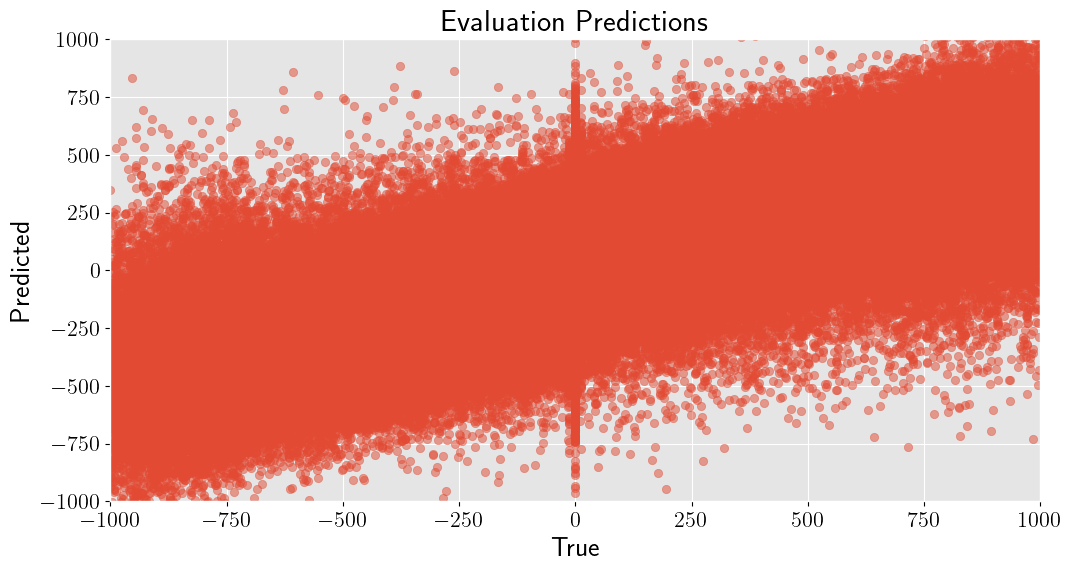

,Metric,Value
0,Spearman Rank,0.703178
1,Accuracy (±200),0.816451
2,RMSE,190.647400
3,Accuracy (sign),0.718052
4,Recall (white),0.856867
5,Recall (black),0.720133
6,R^2,0.523366


In [7]:
mm, dm = load_model("xgb_four_full_rd")
y_pred = mm.predict(dm.X_test)
evaluate(mm, dm)

We can also test the model on the second dataset `random_evals.csv`, which is truly independent of any data that has gone into our final model (not even for hyperparameter-optimization).

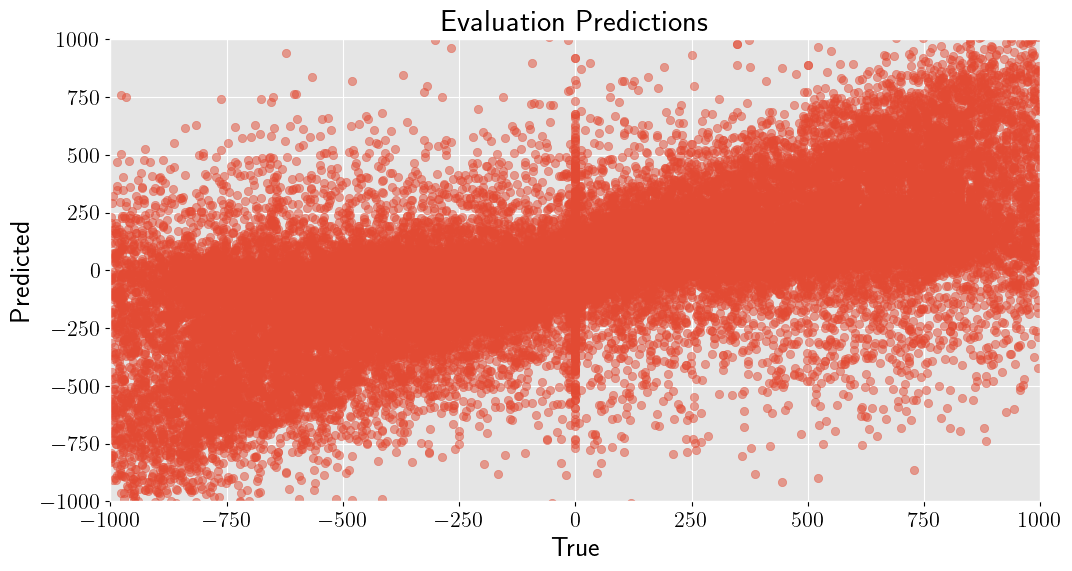

,Metric,Value
0,Spearman Rank,0.676181
1,Accuracy (±200),0.558160
2,RMSE,352.899567
3,Accuracy (sign),0.788600
4,Recall (white),0.864256
5,Recall (black),0.744589
6,R^2,0.391291


In [8]:
dm = DataManager(
    filepath=str(DATASET_RANDOM_FILE),
    read_size=1_000_000,
    sample_size=100_000,
    test_size=0.5,
)
mm.predict(dm.X_test)
evaluate(mm, dm)

The last set of positions we have is the `tactical_evals.csv`, which are positions from chess puzzles. These are usually complicated positions with tricky tactics and sneaky winning ideas. We expect our model to not perform really well on this dataset, since it does not have any information about possible moves, only about the current state of the chess table.

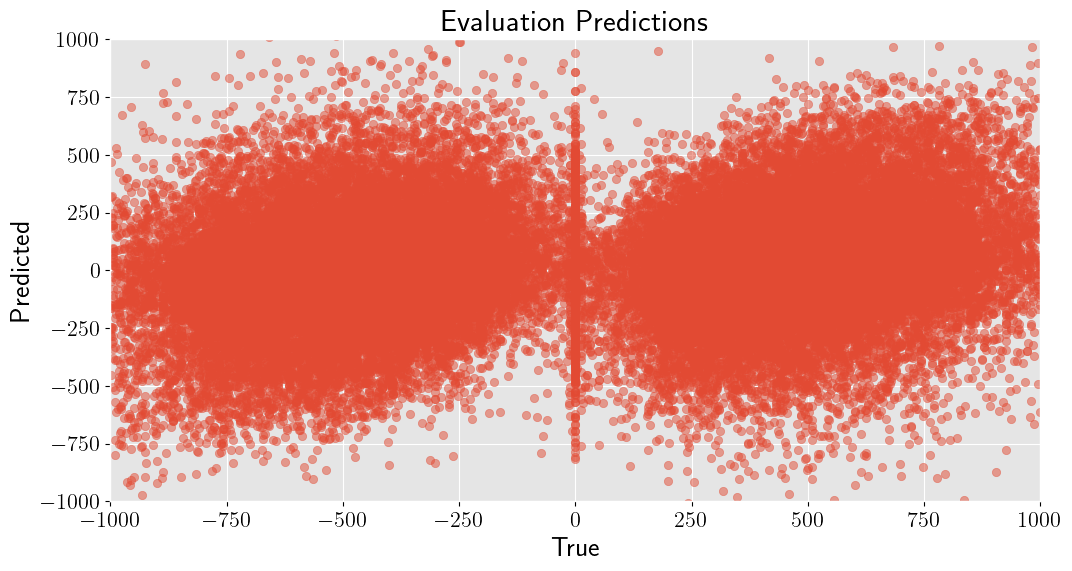

,Metric,Value
0,Spearman Rank,0.201154
1,Accuracy (±200),0.171420
2,RMSE,542.886597
3,Accuracy (sign),0.551820
4,Recall (white),0.600293
5,Recall (black),0.516287
6,R^2,-0.053649


In [9]:
dm = DataManager(
    filepath=str(DATASET_TACTICS_FILE),
    read_size=1_000_000,
    sample_size=100_000,
    test_size=0.5,
)
mm.predict(dm.X_test)
evaluate(mm, dm)

Indeed, the model breaks on these tricky positions.

We can extract the feature importance from our trained model.

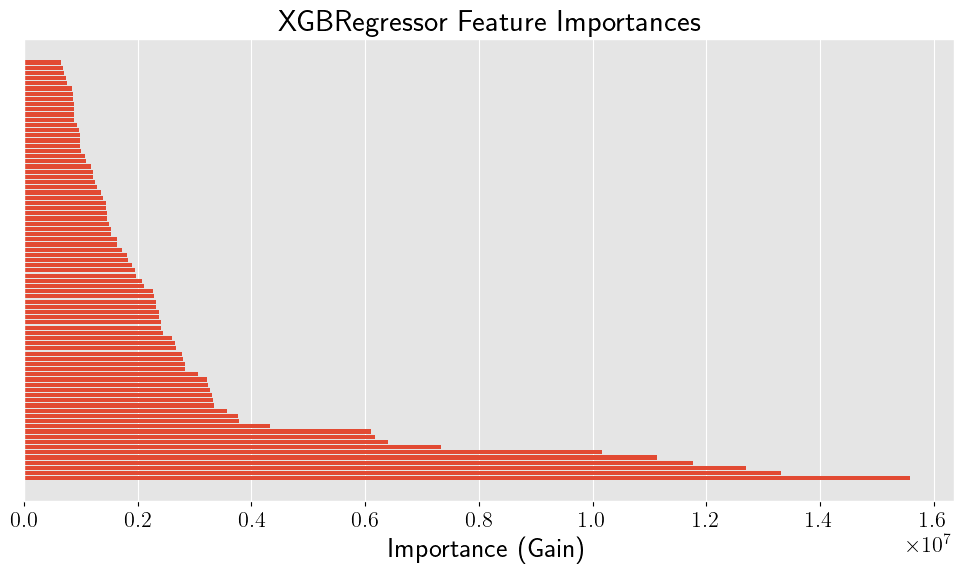

In [10]:
importance_dict = mm.model.get_booster().get_score(importance_type="gain")

importance_df = pd.DataFrame({
    "feature": list(importance_dict.keys()),
    "importance": list(importance_dict.values())
}).sort_values(by="importance", ascending=False)
importance_df["importance_rescaled"] = importance_df["importance"] / importance_df["importance"].max()
importance_df["importance_fraction"] = importance_df["importance"] / importance_df["importance"].sum()

plt.barh(importance_df["feature"], importance_df["importance"])
plt.yticks([])  # Hide y-axis labels
plt.xlabel("Importance (Gain)")
plt.title("XGBRegressor Feature Importances")
plt.show()

We see that around 10 features have the main importance for our model, but nevertheless, all the other ones are crucial as well, since the value of their gain is still high. Let's see the exact numbers.

In [11]:
importance_df.sort_values(by="importance", ascending=False)

,feature,importance,importance_rescaled,importance_fraction
63,SemiOpen_Columns_White,1.557248e+07,1.000000,0.066300
70,SemiOpen_Columns_Black,1.331666e+07,0.855141,0.056696
3,Black_Piece_Value,1.269847e+07,0.815443,0.054064
2,White_Piece_Value,1.176850e+07,0.755724,0.050105
68,Controlled_Squares_White,1.113746e+07,0.715202,0.047418
...,...,...,...,...
61,Central_Squares_Control_White,7.527761e+05,0.048340,0.003205
60,Undefended_Points_Black,7.352342e+05,0.047214,0.003130
55,Undefended_Points_White,7.067208e+05,0.045383,0.003009
54,Undefended_Pieces_White,6.814074e+05,0.043757,0.002901


We see here that the most important feature (or the one that contributes the most to the loss function gains) is the count of semi-open white columns, followed by the count for the black pieces. Fraction-wise, none of these are totally dominant, so we can't say that the model is guided by a simple combination of a couple of features. Even the less significant ones that contribute around 7% of the total gain together make up a good chunk of the model's _intelligence_.